# **1. Perkenalan Dataset**


* Dataset   : Loan Prediction Dataset
* Sumber    : https://www.kaggle.com/datasets/mosaadhendam/loan-prediction-dataset

* Deskripsi : Dataset Prediksi Pinjaman (Loan Prediction Dataset) berisi 2.000 data dengan 6 fitur utama yang menggambarkan individu yang mengajukan pinjaman. Dataset ini dirancang untuk mensimulasikan skenario persetujuan pinjaman di dunia nyata dan mencakup berbagai atribut, seperti usia, pendapatan, skor kredit, jumlah pinjaman, jangka waktu pinjaman, dan status pekerjaan. Variabel target, yaitu Loan_Approved, menunjukkan apakah suatu pengajuan pinjaman disetujui (1) atau ditolak (0). Dataset ini dapat digunakan untuk membangun dan mengevaluasi model machine learning dalam tugas klasifikasi, khususnya untuk memprediksi kelayakan persetujuan pinjaman berdasarkan karakteristik pemohon.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Proyek Membangun Sistem Machine Learning Alika Raisya/Eksperimen_SML_Alika-Raisya/dataset_raw/loan_prediction_dataset.csv'
df = pd.read_csv(file_path)

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [ ]:
df.head(10)

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1
2,46,58827,779,39687,60,Self-Employed,0
3,32,127188,364,16886,24,Unemployed,0
4,60,25655,307,26256,36,Unemployed,0
5,25,64859,600,31005,36,Employed,0
6,38,73625,642,7638,24,Employed,0
7,56,72098,730,38419,36,Self-Employed,0
8,36,35251,723,34377,36,Employed,0
9,40,142413,631,41708,60,Employed,0


In [ ]:
print("Jumlah baris dan kolom:", df.shape)

Jumlah baris dan kolom: (2000, 7)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                2000 non-null   int64 
 1   Income             2000 non-null   int64 
 2   Credit_Score       2000 non-null   int64 
 3   Loan_Amount        2000 non-null   int64 
 4   Loan_Term          2000 non-null   int64 
 5   Employment_Status  2000 non-null   object
 6   Loan_Approved      2000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 109.5+ KB


In [ ]:
df.describe()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Loan_Approved
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,43.805500,84533.585000,577.055000,25460.315000,35.47800,0.171000
std,14.929203,37771.169751,157.525951,14116.737774,16.98587,0.376603
min,18.000000,20155.000000,300.000000,1060.000000,12.00000,0.000000
25%,31.000000,50925.250000,440.000000,13444.250000,24.00000,0.000000
50%,44.000000,84073.500000,578.500000,25446.000000,36.00000,0.000000
75%,56.000000,117523.250000,715.250000,37949.250000,48.00000,0.000000
max,69.000000,149992.000000,849.000000,49994.000000,60.00000,1.000000


In [ ]:
print("Jumlah duplikat:", df.duplicated().sum())

Jumlah duplikat: 0


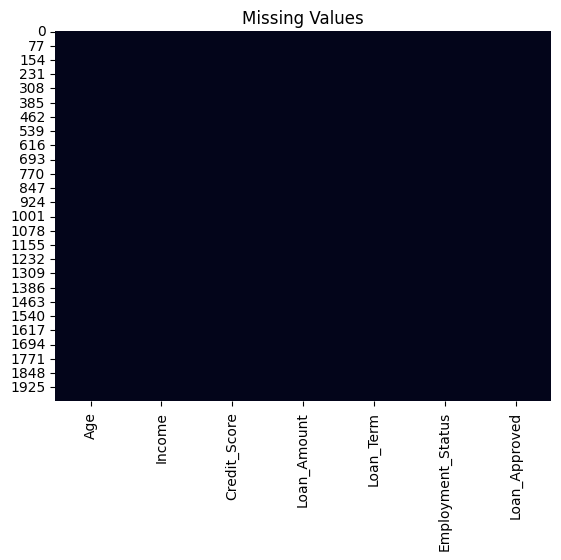

In [ ]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

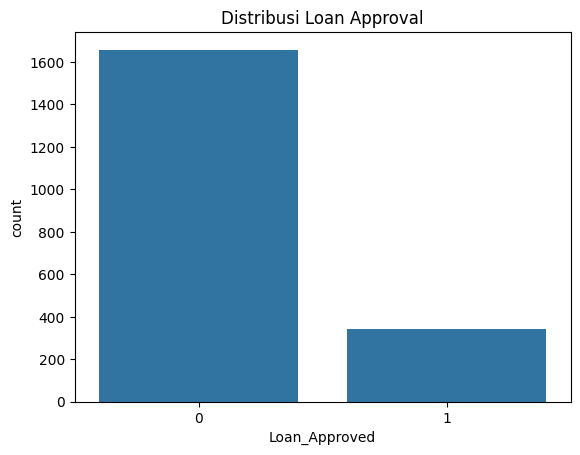

In [ ]:
sns.countplot(data=df, x='Loan_Approved')
plt.title('Distribusi Loan Approval')
plt.show()

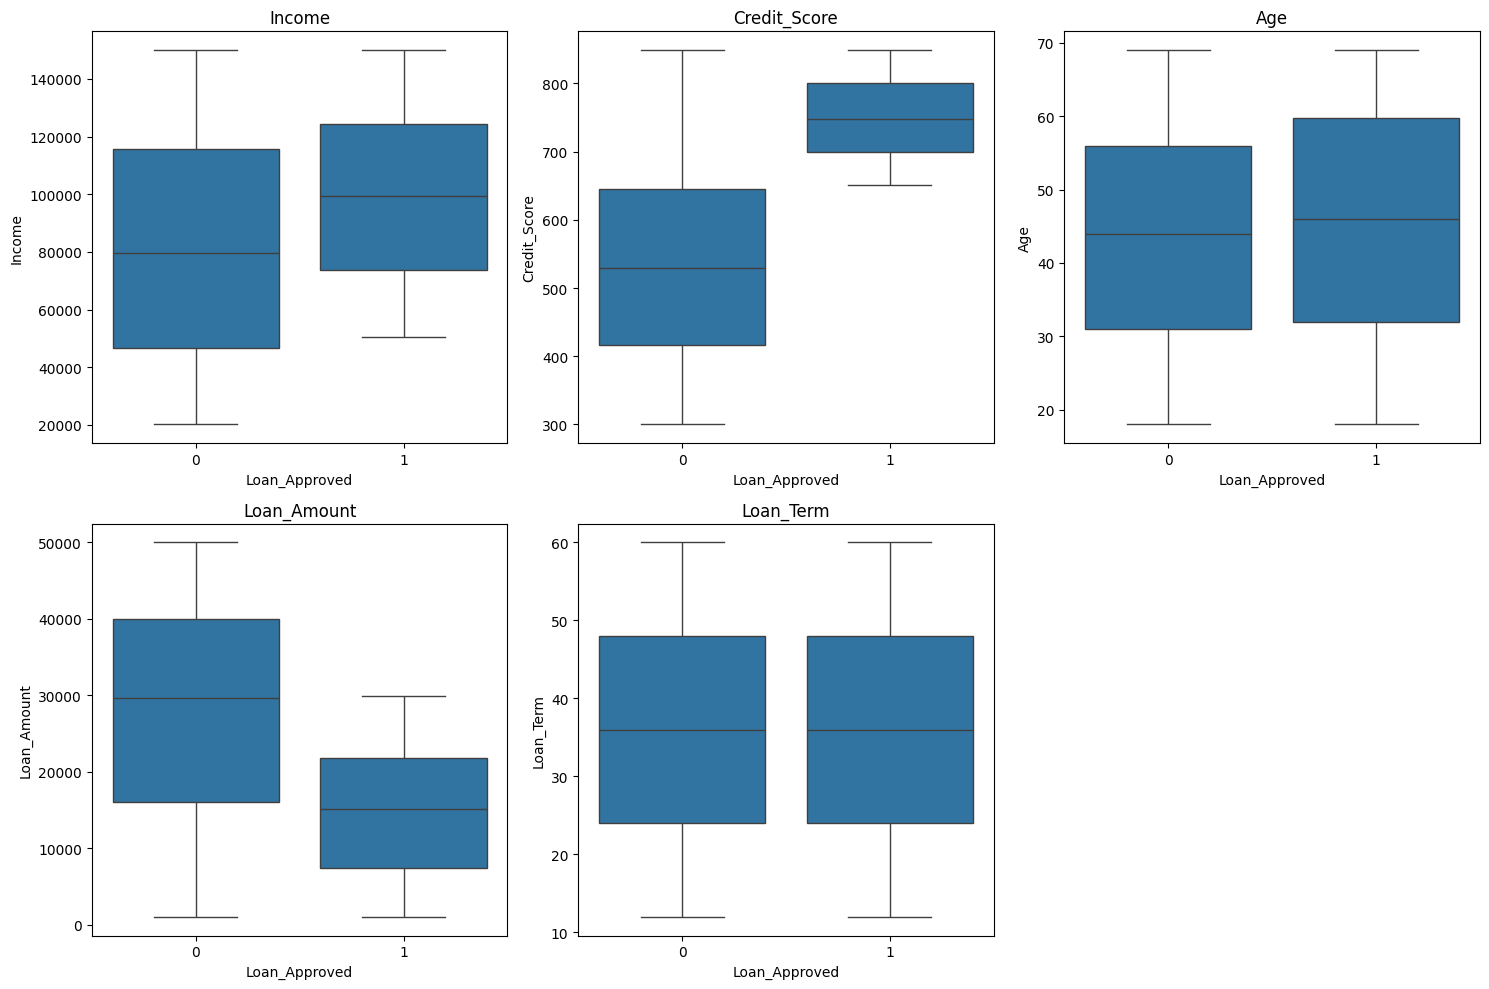

In [ ]:
#Hubungan Fitur dengan Target
num_cols = ['Income', 'Credit_Score', 'Age', 'Loan_Amount', 'Loan_Term']

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(
        data=df,
        x='Loan_Approved',
        y=col
    )
    plt.title(col)

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

# pastikan target tidak ikut
target_column = 'Loan_Approved'

if target_column in numeric_features:
    numeric_features.remove(target_column)

if target_column in categorical_features:
    categorical_features.remove(target_column)

print("Numerik:", numeric_features)
print("Kategorikal:", categorical_features)

Numerik: ['Age', 'Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term']
Kategorikal: ['Employment_Status']


In [ ]:
# Encoding kategorikal
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# Scaling numerik
scaler = StandardScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features])

In [ ]:
X = df.drop('Loan_Approved', axis=1)
y = df['Loan_Approved']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(1400, 7)
(600, 7)


In [ ]:
X_train_df = pd.DataFrame(X_train.toarray() if hasattr(X_train, "toarray") else X_train)
X_test_df = pd.DataFrame(X_test.toarray() if hasattr(X_test, "toarray") else X_test)

X_train_df.to_csv("X_train.csv", index=False)
X_test_df.to_csv("X_test.csv", index=False)

y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

In [ ]:
from joblib import dump

preprocessing_data = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test
}

dump(preprocessing_data, 'preprocessing.pkl')

['preprocessing.pkl']